# AICE 모의고사 2회 - 온라인 쇼핑 판매량 예측

## 문제 시나리오

온라인 쇼핑몰의 제품 및 고객 데이터를 분석 및 전처리한 후 머신러닝과 딥러닝으로 특정 제품의 월별 판매량을 예측하고 결과를 분석하세요.

---

## 2-1 | 라이브러리 임포트 및 데이터 로딩

### 【 문제 】

- pandas를 pd로 임포트하는 코드를 작성하고 실행하세요.
- scikit-learn 패키지를 사전 임포트하는 코드를 작성하고 실행하세요.
- product_info.json을 읽어 데이터프레임 변수 df_product에 저장하세요.
- customer_demographics.csv를 읽어 데이터프레임 변수 df_customer에 저장하세요.


In [227]:
import pandas as pd
import sklearn as sk

In [228]:
### 데이터로딩

In [229]:
df_product = pd.read_json('C:/juehyeon/aice_test/기출문제/2.온라인쇼핑판매량예측/product info.json')

In [230]:
df_product.head()

,ProductID,Category,Price,Rating,ReviewsCount,LaunchYear,PromotionApplied
0,1,Clothing,880,1.7,71,2022,Yes
1,2,Electronics,7779,1.4,458,2022,No
2,3,Electronics,230,1.1,769,2021,No
3,4,Electronics,1284,2.2,21,2022,No
4,5,Electronics,574,3.4,681,2021,No


In [231]:
df_customer = pd.read_csv('C:/juehyeon/aice_test/기출문제/2.온라인쇼핑판매량예측/customer demographics.csv')

In [232]:
df_customer.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   ProductID          97 non-null     float64
 1   AvgCustomerAge     100 non-null    int64  
 2   AvgCustomerIncome  100 non-null    int64  
 3   RegionPopularity   100 non-null    int64  
 4   MonthlySales       96 non-null     float64
dtypes: float64(2), int64(3)
memory usage: 4.0 KB


## 2-2 | 데이터 병합 및 초기 탐색

### 【 문제 】

- ProductID를 기준 키(on)로 사용하여 inner 방식으로 두 데이터를 병합해 df를 생성하세요.
- 병합된 df의 기본 정보(컬럼, 데이터 타입, 결측치 등)를 확인하세요.
- df의 상위 5개 행을 출력해 구조를 빠르게 파악하세요.

In [233]:
df_customer.head()

,ProductID,AvgCustomerAge,AvgCustomerIncome,RegionPopularity,MonthlySales
0,1.0,46,57532,46,375.0
1,2.0,23,35713,69,58.0
2,3.0,42,95545,56,352.0
3,4.0,62,67892,33,335.0
4,5.0,18,130497,96,423.0


In [234]:
df = pd.merge(df_product, df_customer, on = 'ProductID', how ='inner')

In [235]:
df.head()

,ProductID,Category,Price,Rating,ReviewsCount,LaunchYear,PromotionApplied,AvgCustomerAge,AvgCustomerIncome,RegionPopularity,MonthlySales
0,1,Clothing,880,1.7,71,2022,Yes,46,57532,46,375.0
1,2,Electronics,7779,1.4,458,2022,No,23,35713,69,58.0
2,3,Electronics,230,1.1,769,2021,No,42,95545,56,352.0
3,4,Electronics,1284,2.2,21,2022,No,62,67892,33,335.0
4,5,Electronics,574,3.4,681,2021,No,18,130497,96,423.0


## 2-3 | 범주형 변수 로트 시각화 및 데이터 경제

### 【 문제 】

- matplotlib.pyplot을 plt, seaborn을 sns로 임포트하세요.
- Category 분포를 countplot으로 시각화하세요(정제 전).
- Category 중 'Misc'인 행을 삭제한 뒤, 삭제 전후 분포를 비교 시각화하세요.
- 삭제된 행의 개수를 답안03 변수에 저장하세요(예: 답안03 = 5).

In [236]:
import matplotlib.pyplot as plt

In [237]:
import seaborn as sns

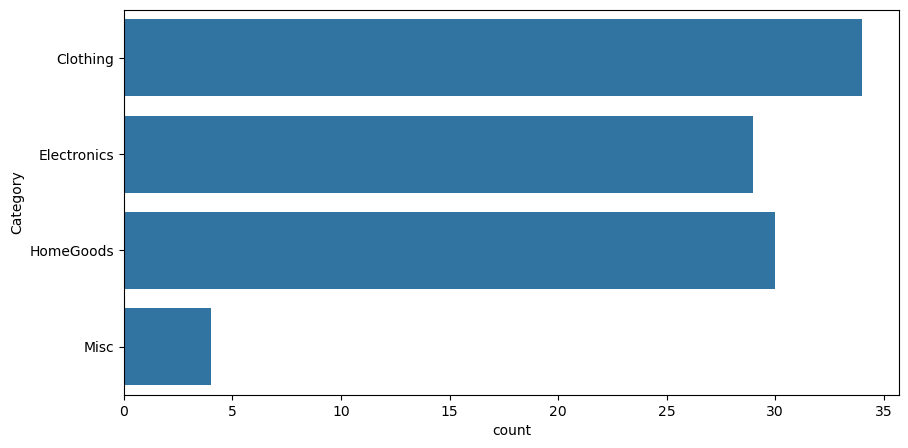

In [238]:
plt.figure(figsize = (10, 5))
sns.countplot(data = df['Category'])
plt.show()

In [239]:
df['Category'].unique()

array(['Clothing', 'Electronics', 'HomeGoods', 'Misc'], dtype=object)

In [240]:
답안03 = df[df['Category'] == 'Misc'].shape[0]

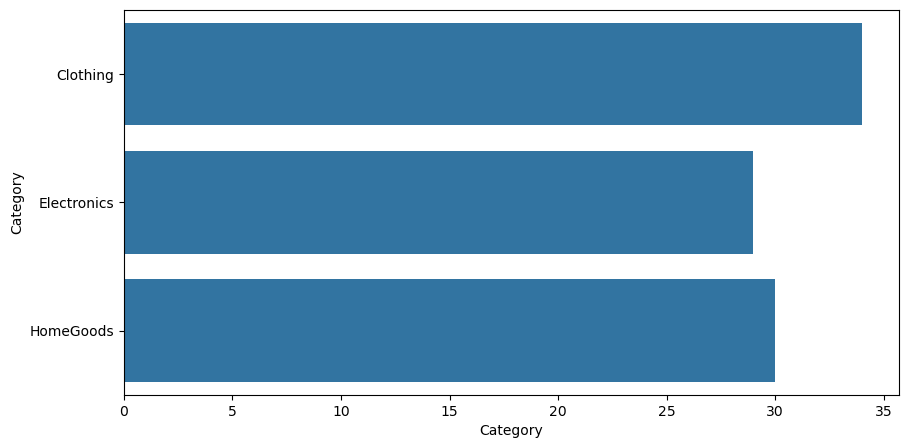

In [241]:
df = df[df['Category'] != 'Misc'].copy()
plt.figure(figsize = (10,5))
sns.countplot(data = df['Category'])
plt.xlabel('Category')
plt.show()

## 2-4 | 수치형 변수 관계 시각화 및 이상치 탐색

### 【 문제 】

- Price(x축)와 MonthlySales(y축)의 관계를 jointplot으로 시각화하세요.
- 그래프/데이터를 바탕으로 Price ≥ 5000을 이상치로 간주하고 개수를 답안04에 저장하세요.


8


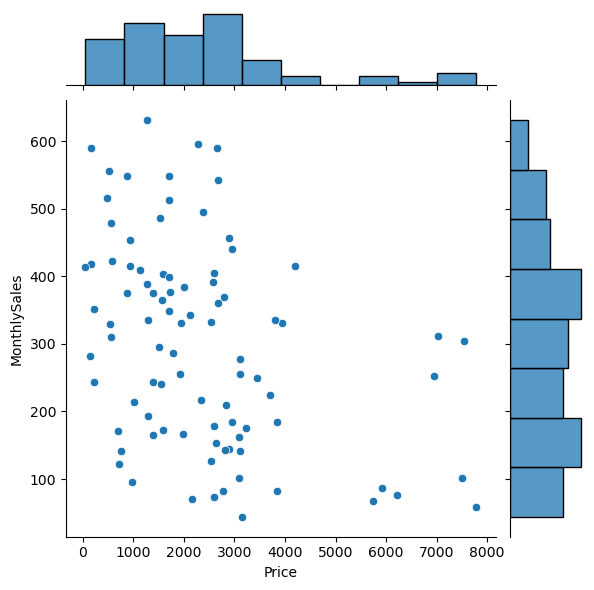

In [242]:
sns.jointplot(
    data = df,
    x = 'Price',
    y = 'MonthlySales'
)

답안04 = df[df['Price'] >= 5000].shape[0]
print(답안04)

## 2-5 | 이상치 및 불필요 컬럼 처리

### 【 문제 】

- Price ≥ 5000인 이상치 행을 삭제하세요.
- 예측에 직접 기여하지 않는 식별자 ProductID 컬럼을 삭제하세요.
- 결과를 df_temp에 저장하세요.

In [243]:
df_temp = df.copy()

In [244]:
df_temp = df_temp.drop('ProductID', axis =1)

In [245]:
df_temp = df_temp[df_temp['Price'] < 5000]

In [246]:
df_temp.info()

<class 'pandas.core.frame.DataFrame'>
Index: 85 entries, 0 to 96
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Category           85 non-null     object 
 1   Price              85 non-null     int64  
 2   Rating             85 non-null     float64
 3   ReviewsCount       85 non-null     int64  
 4   LaunchYear         85 non-null     int64  
 5   PromotionApplied   85 non-null     object 
 6   AvgCustomerAge     85 non-null     int64  
 7   AvgCustomerIncome  85 non-null     int64  
 8   RegionPopularity   85 non-null     int64  
 9   MonthlySales       82 non-null     float64
dtypes: float64(2), int64(6), object(2)
memory usage: 7.3+ KB


## 2-6 | 결측치 처리 및 데이터 타입 변환

### 【 문제 】

- df_temp의 결측치를 확인하세요.
- 결측치가 있는 행을 삭제한 뒤 결과를 df_na에 저장하세요.
- PromotionApplied를 Yes→1, No→0으로 변환하세요.
- 삭제된 결측치 행의 개수를 답안06에 저장하세요.

In [247]:
df_temp.isna().sum()

Category             0
Price                0
Rating               0
ReviewsCount         0
LaunchYear           0
PromotionApplied     0
AvgCustomerAge       0
AvgCustomerIncome    0
RegionPopularity     0
MonthlySales         3
dtype: int64

In [248]:
df_na = df_temp.dropna().copy()

In [249]:
df_na.isna().sum()

Category             0
Price                0
Rating               0
ReviewsCount         0
LaunchYear           0
PromotionApplied     0
AvgCustomerAge       0
AvgCustomerIncome    0
RegionPopularity     0
MonthlySales         0
dtype: int64

In [250]:
initial_row = df_temp.isna().shape[0]

In [251]:
new_row = df_na.isna().shape[0]

In [252]:
답안06 = initial_row - new_row

In [253]:
print(f'답안06 : {답안06}')

답안06 : 3


In [254]:
df_na.info()

<class 'pandas.core.frame.DataFrame'>
Index: 82 entries, 0 to 96
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Category           82 non-null     object 
 1   Price              82 non-null     int64  
 2   Rating             82 non-null     float64
 3   ReviewsCount       82 non-null     int64  
 4   LaunchYear         82 non-null     int64  
 5   PromotionApplied   82 non-null     object 
 6   AvgCustomerAge     82 non-null     int64  
 7   AvgCustomerIncome  82 non-null     int64  
 8   RegionPopularity   82 non-null     int64  
 9   MonthlySales       82 non-null     float64
dtypes: float64(2), int64(6), object(2)
memory usage: 7.0+ KB


In [255]:
df_na['PromotionApplied'] = df_na['PromotionApplied'].map({"Yes" : 1, "No" : 0})

In [256]:
df_na.info()

<class 'pandas.core.frame.DataFrame'>
Index: 82 entries, 0 to 96
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Category           82 non-null     object 
 1   Price              82 non-null     int64  
 2   Rating             82 non-null     float64
 3   ReviewsCount       82 non-null     int64  
 4   LaunchYear         82 non-null     int64  
 5   PromotionApplied   82 non-null     int64  
 6   AvgCustomerAge     82 non-null     int64  
 7   AvgCustomerIncome  82 non-null     int64  
 8   RegionPopularity   82 non-null     int64  
 9   MonthlySales       82 non-null     float64
dtypes: float64(2), int64(7), object(1)
memory usage: 7.0+ KB


## 2-7 | 불필요 컬럼 처리 및 범주형 변수 원-핫 인코딩

### 【 문제 】

- 본 문제에서는 Category와 MonthlySales만 남기고 나머지 컬럼은 삭제하세요(학습 단순화 목적).
- Category(object)를 원-핫 인코딩하여 수치형 변수로 변환하세요.
- 결과를 df_encoded에 저장하세요.


In [257]:
df_encoded = df_na[['Category', 'MonthlySales']].copy()

In [258]:
df_encoded = pd.get_dummies(data = df_encoded, columns = ['Category'])

In [259]:
df_encoded.head()

,MonthlySales,Category_Clothing,Category_Electronics,Category_HomeGoods
0,375.0,True,False,False
2,352.0,False,True,False
3,335.0,False,True,False
4,423.0,False,True,False
5,145.0,True,False,False


## 2-8 | 데이터 분리 및 스케일링

### 【 문제 】

- X는 피처(MonthlySales 제외), y는 타깃(MonthlySales)으로 분리하세요.
- train_test_split으로 80:20 분할, random_state=42로 설정하세요.
- RobustScaler로 X_train, X_valid를 스케일링한 각각 X_train_scaled, X_valid_scaled로 저장하세요.


In [260]:
X = df_encoded.drop(columns = 'MonthlySales')

In [261]:
y = df_encoded['MonthlySales']

In [262]:
from sklearn.model_selection import train_test_split

In [263]:
from sklearn.preprocessing import RobustScaler

In [264]:
X_train, X_valid, y_train, y_valid = train_test_split(X, y, test_size = 0.2, random_state = 42)

In [265]:
rs = RobustScaler()

In [266]:
X_train_scaled = rs.fit_transform(X_train)
X_valid_scaled = rs.transform(X_valid)

## 2-9 | 머신러닝 모델 학습(RandomForestRegressor)

### 【 문제 】

- RandomForestRegressor를 생성하고, random_state=42로 설정하세요.
- X_train_scaled, y_train으로 모델을 학습시키고, 객체를 rf_model에 저장하세요.

In [267]:
from sklearn.ensemble import RandomForestRegressor

In [268]:
rf_model = RandomForestRegressor(random_state = 42)

In [269]:
rf_model.fit(X_train_scaled, y_train)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


## 2-10 | 머신러닝 모델 학습(GradientBoostingRegressor)

### 【 문제 】

- GradientBoostingRegressor를 random_state=42로 생성하세요.
- X_train_scaled, y_train으로 모델을 학습시키고, gb_model에 저장하세요.

In [270]:
from sklearn.ensemble import GradientBoostingRegressor

In [271]:
gb_model = GradientBoostingRegressor(random_state = 42)

In [272]:
gb_model.fit(X_train_scaled, y_train)

,loss,'squared_error'
,learning_rate,0.1
,n_estimators,100
,subsample,1.0
,criterion,'friedman_mse'
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_depth,3
,min_impurity_decrease,0.0
,init,None


## 2-11 | 머신러닝 모델 성능 평가(MAE 비교)

### 【 문제 】

- rf_model, gb_model로 X_valid_scaled에 대한 예측을 수행하세요.
- mean_absolute_error(MAE)로 두 모델의 성능을 계산하세요. (예: 'RandomForest' 또는 'GradientBoosting')
- 더 낮은 MAE의 모델명을 문자열로 답안11에 저장하세요.


In [273]:
rf_model_pred = rf_model.predict(X_valid_scaled)

In [274]:
gb_model_pred = gb_model.predict(X_valid_scaled)

In [275]:
from sklearn.metrics import mean_absolute_error

In [276]:
rf_model_mae = mean_absolute_error(y_test, rf_model_pred)

In [277]:
gb_model_mae = mean_absolute_error(y_test, gb_model_pred)

In [278]:
print(rf_model_mae, '\n', gb_model_mae)

141.05556712889006 
 139.71313333563612


In [279]:
답안11 = 'GradientBoosting'

## 2-12 | 딥러닝 모델 개발 및 학습

### 【 문제 】

- tensorflow/keras를 임포트하고 tf.random.set_seed(1)로 재현성을 확보하세요.
- Dense 층을 사용하는 인공적인 다층 퍼셉트론(MLP/DNN) 회귀 모델을 Sequential로 구성하세요.
- 입력은 2D 텐서(샘플 수, 피처 수)를 그대로 사용합니다(reshape 3D 변환 불필요).
- 은닉 2개 이상에 ReLU 활성화 함수를 적용하고, Dropout(0.2)을 1개 이상 추가하세요.
- 출력은 Dense(1)로 구성하세요(회귀 문제).
- 옵티마이저 'adam', 손실함수 'mse', 평가지표 'mse'로 컴파일하세요.
- epochs=20, batch_size=16으로 학습하고, 검증 데이터는 (X_valid_scaled, y_valid)를 사용하세요.
- 학습 이력은 history_dl에 저장하세요.

In [280]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input, Dropout
tf.random.set_seed(1)

In [281]:
dl_model = Sequential([
    Input(shape = (X_train_scaled.shape[1],)),
    Dense(64, activation = 'relu'),
    Dropout(0.2),
    Dense(32, activation = 'relu'),
    Dense(1)])

In [282]:
dl_model.compile(optimizer = 'adam', loss = 'mse', metrics = ['mse'])

In [283]:
history_dl = dl_model.fit(X_train_scaled, y_train, epochs= 20, batch_size = 16, validation_data = (X_valid_scaled, y_valid))

Epoch 1/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 4s 196ms/step - loss: 129997.1406 - mse: 129997.1406 - val_loss: 78934.4375 - val_mse: 78934.4375
Epoch 2/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step - loss: 129930.7656 - mse: 129930.7656 - val_loss: 78877.6641 - val_mse: 78877.6641
Epoch 3/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - loss: 129843.4609 - mse: 129843.4609 - val_loss: 78820.3125 - val_mse: 78820.3125
Epoch 4/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - loss: 129776.5234 - mse: 129776.5234 - val_loss: 78758.1875 - val_mse: 78758.1875
Epoch 5/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - loss: 129667.9375 - mse: 129667.9375 - val_loss: 78688.8750 - val_mse: 78688.8750
Epoch 6/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - loss: 129585.2188 - mse: 129585.2188 - val_loss: 78611.3516 - val_mse: 78611.3516
Epoch 7/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - loss: 129463.0156 - mse: 129463.0156 - val_loss: 78524.4453 - val_mse: 78524.4453
Epoch 8/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step - loss: 129345.7500

## 2-13. 딥러닝 학습 곡선 시각화
### 【 문제 】

- history_dl의 mse와 val_mse를 시각화하세요.
- Epochs에 따른 학습/검증 mse 추이를 같은 그래프에 표시하세요.


In [284]:
train_mse = history_dl.history['mse']
val_mse = history_dl.history['val_mse']
epochs = range(1, len(train_mse)+1)

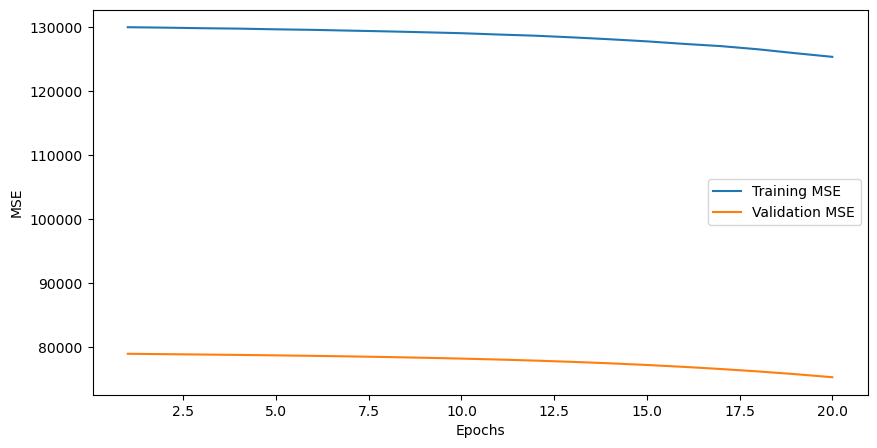

In [285]:
plt.figure(figsize = (10,5))
plt.plot(epochs, train_mse, label = 'Training MSE')
plt.plot(epochs, val_mse, label = 'Validation MSE')
plt.xlabel('Epochs')
plt.ylabel('MSE')
plt.legend()
plt.show()

## 2-14 | 최종 모델 선택 및 결론 도출

### 【 문제 】

- rf_model, gb_model, dl_model의 검증 성능을 MAE로 비교하세요.
- 가장 낮은 MAE를 보인 모델명을 답안14에 저장하세요 (예: 'RandomForest', 'GradientBoosting', 'DeepLearning (DNN)')
- 성능이 우수하더라도 학습시간/복잡도/해석 가능성 관점에서 실무 이들을 주석으로 작성하세요.